### *Usecase*
- Demand Forecasting System for Optimizing Inventory and Supply Chain Efficiency Using 
Historical Sales Data 

### Problem Statment
- The company has accumulated transactional data from December 2021 to December 2023, 
consisting of stock code, transaction dates, and quantities sold and etc. The company 
requires a system to forecast the demand for the next 15 weeks for its top 10 best-selling 
products.
- The goal is to estimate future demand accurately to maintain optimal stock levels, 
ensuring that the supply chain remains efficient and meets customer demands. The solution 
should leverage the historical data to predict future demand trends and support inventory 
management decisions. 

### **Data Exploration and Preprocessing**

- Load the Data


In [ ]:
import pandas as pd
import numpy as np


import seaborn as sns
import matplotlib.pyplot as plt




In [ ]:
import pandas as pd

# Load transaction data
transaction_01 = pd.read_csv('Transactional_data_retail_01.csv')
transaction_02 = pd.read_csv('Transactional_data_retail_02.csv')




In [ ]:
transaction_01.head()

,Invoice,StockCode,Quantity,Price,Customer ID,InvoiceDate
0,489434,85048,12,6.95,13085.0,01 December 2021
1,489434,79323P,12,6.75,13085.0,01 December 2021
2,489434,79323W,12,6.75,13085.0,01 December 2021
3,489434,22041,48,2.10,13085.0,01 December 2021
4,489434,21232,24,1.25,13085.0,01 December 2021


In [ ]:
transaction_01.shape

(525461, 6)

In [ ]:
transaction_01.isnull().sum() #Cutomer id having the null values.

,0
Invoice,0
StockCode,0
Quantity,0
Price,0
Customer ID,107927
InvoiceDate,0


In [ ]:
transaction_01.sample(10)

,Invoice,StockCode,Quantity,Price,Customer ID,InvoiceDate
276055,516194,22149,80,1.85,13881.0,19 July 2022
58624,494661,21931,1,1.95,13634.0,17 January 2022
364984,524747,22725,4,3.75,14156.0,30 September 2022
166140,505083,22326,6,2.95,12623.0,20 April 2022
182293,506708,85099B,1,1.95,15719.0,02 May 2022
151561,503823,21527,2,16.98,NaN,07 April 2022
199033,508493,21922,1,7.95,17085.0,16 May 2022
354535,523889,22732,20,1.25,14226.0,24 September 2022
147621,503428,84750A,1,4.21,NaN,31 March 2022
113143,500233,22083,1,2.95,13544.0,05 March 2022


In [ ]:
transaction_02 = pd.read_csv("/content/Transactional_data_retail_02.csv")

In [ ]:
transaction_02.shape

(541910, 6)

In [ ]:
transaction_02.head()

,Invoice,StockCode,Quantity,Price,Customer ID,InvoiceDate
0,536365,85123A,6,2.55,17850.0,01-12-2022
1,536365,71053,6,3.39,17850.0,01-12-2022
2,536365,84406B,8,2.75,17850.0,01-12-2022
3,536365,84029G,6,3.39,17850.0,01-12-2022
4,536365,84029E,6,3.39,17850.0,01-12-2022


In [ ]:
transaction_02.isnull().sum()

,0
Invoice,0
StockCode,0
Quantity,0
Price,0
Customer ID,135080
InvoiceDate,0


- so,Since both have the same columns, you can concatenate them into a single dataset for analysis.
-

In [ ]:
# Combine the two transactional datasets
transactions = pd.concat([transaction_01, transaction_02])

# Check for missing values and handle them
transactions.isnull().sum()  # Identify missing values
#transactions.dropna(subset=['Customer ID', 'Quantity', 'Price'], inplace=True)  # Drop rows with missing values


,0
Invoice,0
StockCode,0
Quantity,0
Price,0
Customer ID,243007
InvoiceDate,0


In [ ]:
transactions.head()

,Invoice,StockCode,Quantity,Price,Customer ID,InvoiceDate
0,489434,85048,12,6.95,13085.0,01 December 2021
1,489434,79323P,12,6.75,13085.0,01 December 2021
2,489434,79323W,12,6.75,13085.0,01 December 2021
3,489434,22041,48,2.10,13085.0,01 December 2021
4,489434,21232,24,1.25,13085.0,01 December 2021


In [ ]:
# Load customer demographics
customer_demo= pd.read_csv('CustomerDemographics.csv')

In [ ]:
customer_demo.head()

,Customer ID,Country
0,13085,United Kingdom
1,13078,United Kingdom
2,15362,United Kingdom
3,18102,United Kingdom
4,12682,France


In [ ]:
customer_demo .isnull().sum()

,0
Customer ID,0
Country,0


In [ ]:
# Load product info

product_info = pd.read_csv('ProductInfo.csv')

In [ ]:
product_info.head()

,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
1,71053,WHITE METAL LANTERN
2,84406B,CREAM CUPID HEARTS COAT HANGER
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE
4,84029E,RED WOOLLY HOTTIE WHITE HEART.


In [ ]:
product_info.isnull().sum()

,0
StockCode,0
Description,2451


In [ ]:
product_info.sample(10)

,StockCode,Description
8049,85190,NaN
4967,23610,SET 10 CARDS CHRISTMAS ROBIN 17095
5873,17165B,ASS COL LARGE SAND GECKO P'WEIGHT
7133,84857A,SILVER MONTE CARLO HANDBAG
7633,21307,NaN
8128,85129B,NaN
3398,23128,DOLLCRAFT BOY JEAN-PAUL
3423,85172,?sold as sets?
5411,21843,smashed
6498,21701,SET 6 MINI SUSHI SET FRIDGE MAGNETS


- Merge with Product and Customer Data

In [ ]:
# Merge with product and customer demographics data
transactions = transactions.merge(product_info, on='StockCode', how='left')
transactions = transactions.merge(customer_demo, on='Customer ID', how='left')


In [ ]:
transactions.head()

,Invoice,StockCode,Quantity,Price,Customer ID,InvoiceDate,Description_x,Country_x,Description_y,Country_y
0,489434,85048,12,6.95,13085.0,01 December 2021,15CM CHRISTMAS GLASS BALL 20 LIGHTS,United Kingdom,15CM CHRISTMAS GLASS BALL 20 LIGHTS,United Kingdom
1,489434,79323P,12,6.75,13085.0,01 December 2021,PINK CHERRY LIGHTS,United Kingdom,PINK CHERRY LIGHTS,United Kingdom
2,489434,79323P,12,6.75,13085.0,01 December 2021,PINK CHERRY LIGHTS,United Kingdom,"Unsaleable, destroyed.",United Kingdom
3,489434,79323P,12,6.75,13085.0,01 December 2021,PINK CHERRY LIGHTS,United Kingdom,NaN,United Kingdom
4,489434,79323P,12,6.75,13085.0,01 December 2021,"Unsaleable, destroyed.",United Kingdom,PINK CHERRY LIGHTS,United Kingdom


- Convert InvoiceDate to DateTime

In [ ]:
# Convert InvoiceDate to datetime, specifying dayfirst=True to handle day-month-year format
transactions['InvoiceDate'] = pd.to_datetime(transactions['InvoiceDate'], dayfirst=True, errors='coerce')

# Check for any remaining null values after conversion
print(transactions['InvoiceDate'].isnull().sum())


2696872


- Create Revenue Column

In [ ]:
# Calculate revenue
transactions['Revenue'] = transactions['Quantity'] * transactions['Price']


In [ ]:
transactions.head()

,Invoice,StockCode,Quantity,Price,Customer ID,InvoiceDate,Description_x,Country_x,Description_y,Country_y,Revenue
0,489434,85048,12,6.95,13085.0,2021-12-01,15CM CHRISTMAS GLASS BALL 20 LIGHTS,United Kingdom,15CM CHRISTMAS GLASS BALL 20 LIGHTS,United Kingdom,83.4
1,489434,79323P,12,6.75,13085.0,2021-12-01,PINK CHERRY LIGHTS,United Kingdom,PINK CHERRY LIGHTS,United Kingdom,81.0
2,489434,79323P,12,6.75,13085.0,2021-12-01,PINK CHERRY LIGHTS,United Kingdom,"Unsaleable, destroyed.",United Kingdom,81.0
3,489434,79323P,12,6.75,13085.0,2021-12-01,PINK CHERRY LIGHTS,United Kingdom,NaN,United Kingdom,81.0
4,489434,79323P,12,6.75,13085.0,2021-12-01,"Unsaleable, destroyed.",United Kingdom,PINK CHERRY LIGHTS,United Kingdom,81.0


### **Step 2: Exploratory Data Analysis (EDA)**

- 2.1 Customer-Level Summary Statistics

In [ ]:
# Customer-level statistics
customer_summary = transactions.groupby('Customer ID').agg({
    'Quantity': 'sum',
    'Revenue': 'sum'
}).reset_index()

customer_summary.head()


,Customer ID,Quantity,Revenue
0,12346.0,253,614.36
1,12347.0,15705,41484.14
2,12348.0,8912,5885.44
3,12349.0,9279,27440.12
4,12350.0,860,1271.00


- 2.2 Product-Level Summary Statistics

In [ ]:
# Product-level statistics
product_summary = transactions.groupby('StockCode').agg({
    'Quantity': 'sum',
    'Revenue': 'sum'
}).reset_index()

product_summary.head()


,StockCode,Quantity,Revenue
0,10002,31160,24857.40
1,10002R,4,20.57
2,10080,5373,1163.61
3,10109,0,6.72
4,10120,-33400,559.20


- 2.3 Visualize Sales Trends Over Time

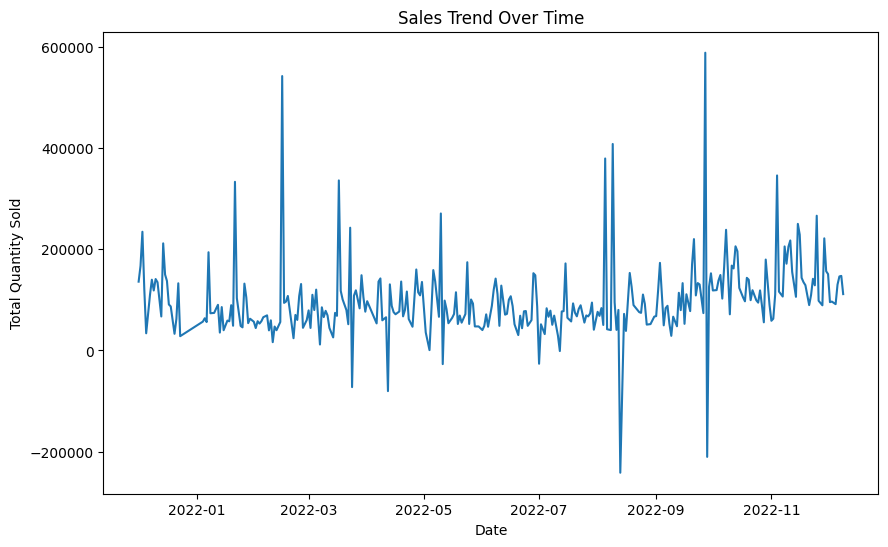

In [ ]:
import matplotlib.pyplot as plt

# Group by date and calculate daily sales
daily_sales = transactions.groupby(transactions['InvoiceDate'].dt.date)['Quantity'].sum()

# Plot the sales trend
plt.figure(figsize=(10,6))
plt.plot(daily_sales)
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Quantity Sold')
plt.show()


### **Step 3: Identify Top 10 Products**

- 3.1 Top 10 Products by Quantity Sold

In [ ]:
# Top 10 products based on quantity sold
top_10_products = product_summary.nlargest(10, 'Quantity')
top_10_products


,StockCode,Quantity,Revenue
4645,85123A,2401650,6343000.50
2394,23084,1961344,4272421.76
1755,22423,1648896,20980073.60
663,21181,1609088,3249914.88
4615,85099B,1531824,2900456.16
283,20713,1518021,3316229.91
1549,22197,1269808,1284801.12
4310,84879,726345,1182724.65
4727,85175,614411,321377.28
2053,22734,595392,1726392.32


- 3.2 Top 10 Products by Revenue

In [ ]:
# Top 10 products based on revenue
top_10_revenue_products = product_summary.nlargest(10, 'Revenue')
top_10_revenue_products


,StockCode,Quantity,Revenue
1755,22423,1648896,20980073.60
4645,85123A,2401650,6343000.50
2394,23084,1961344,4272421.76
283,20713,1518021,3316229.91
663,21181,1609088,3249914.88
4615,85099B,1531824,2900456.16
1829,22502,142452,2198673.00
2053,22734,595392,1726392.32
259,20685,247225,1680477.00
1255,21843,139575,1530465.00


### **Step 4: Time-Series Forecasting**

- Let’s forecast the demand for the top 10 products based on quantity sold using ARIMA.

In [ ]:
# For time-series forecasting, we need to aggregate weekly sales data
weekly_sales = transactions.groupby([transactions['InvoiceDate'].dt.to_period('W'), 'StockCode'])['Quantity'].sum().reset_index()

# Filter for top 10 products
top_10_stockcodes = top_10_products['StockCode'].tolist()
weekly_sales_top_10 = weekly_sales[weekly_sales['StockCode'].isin(top_10_stockcodes)]


In [ ]:
weekly_sales_top_10

,InvoiceDate,StockCode,Quantity
149,2021-11-29/2021-12-05,20713,6723
398,2021-11-29/2021-12-05,21181,12160
1098,2021-11-29/2021-12-05,22197,10736
1821,2021-11-29/2021-12-05,84879,17883
1990,2021-11-29/2021-12-05,85099B,18880
...,...,...,...
102396,2022-12-05/2022-12-11,22734,3840
102988,2022-12-05/2022-12-11,84879,6669
103115,2022-12-05/2022-12-11,85099B,12176
103127,2022-12-05/2022-12-11,85123A,25875


### **4.2 ARIMA Model for Forecasting**
- Let’s forecast for one of the top products using ARIMA. You can loop through all top 10 products later

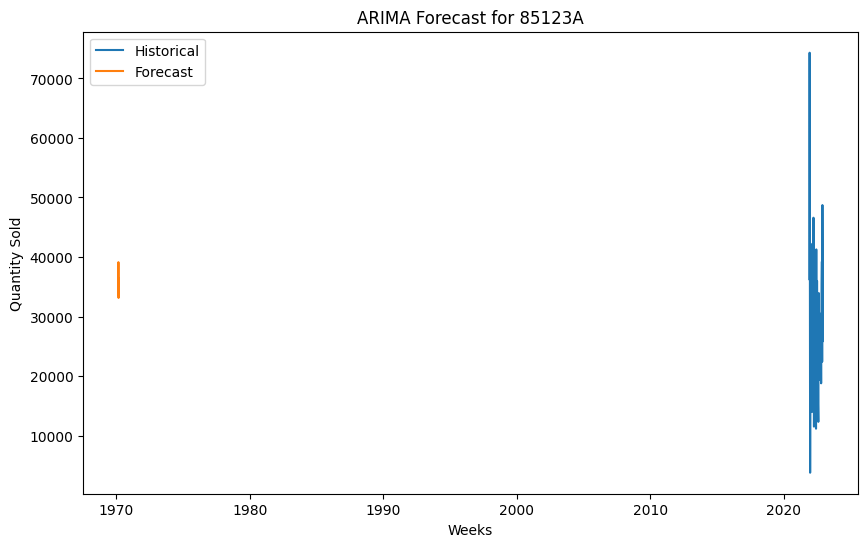

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Select data for one product, say the first in the top 10
product_code = top_10_stockcodes[0]
product_sales = weekly_sales_top_10[weekly_sales_top_10['StockCode'] == product_code].set_index('InvoiceDate')['Quantity']

# Build and fit ARIMA model
model = ARIMA(product_sales, order=(5, 1, 0))  # ARIMA(5,1,0) is an example, you can tune the parameters
arima_result = model.fit()

# Forecast for the next 15 weeks
forecast = arima_result.forecast(steps=15)

# Plot the forecast
plt.figure(figsize=(10,6))
plt.plot(product_sales.index.to_timestamp(), product_sales, label='Historical')
plt.plot(np.arange(len(product_sales), len(product_sales)+15), forecast, label='Forecast')
plt.title(f'ARIMA Forecast for {product_code}')
plt.xlabel('Weeks')
plt.ylabel('Quantity Sold')
plt.legend()
plt.show()


### **Step 5: Machine Learning Mode(Non-Time-Series)**
- 5.1 Feature Engineering
- Create new features based on customer demographics, product categories, and historical sales averages.

In [ ]:
# Create features such as average sales per customer, country
transactions['Avg_Quantity_Customer'] = transactions.groupby('Customer ID')['Quantity'].transform('mean')
transactions['Total_Quantity_StockCode'] = transactions.groupby('StockCode')['Quantity'].transform('sum')


- 5.2 Train XGBoost Model

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# Prepare data for XGBoost
X = transactions[['Avg_Quantity_Customer', 'Total_Quantity_StockCode', 'Price']]  # Example features
y = transactions['Quantity']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
model = XGBRegressor()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)


In [ ]:
y_pred

array([14.484445  , 15.005305  ,  1.2592398 , ...,  0.50892794,
       12.812445  ,  1.4334676 ], dtype=float32)

### **Step 6: Model Evaluation**


- 6.1 Error Metrics
- Evaluate the performance of the ARIMA and XGBoost models using RMSE and MAE.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# RMSE and MAE for ARIMA (for example)
arima_rmse = np.sqrt(mean_squared_error(product_sales, arima_result.fittedvalues))
arima_mae = mean_absolute_error(product_sales, arima_result.fittedvalues)

print(f'ARIMA RMSE: {arima_rmse}, ARIMA MAE: {arima_mae}')


ARIMA RMSE: 13192.666297741454, ARIMA MAE: 8980.230774665373


### Step 7: App Development (Streamlit)